
# Hyperparam_Optimierung — 5 Modelle × 3 Komplexitäten (15 Läufe)

**Neu & Anforderungen**

- Optimierung für **alle `COMPLEXITY_PRESETS`** aus `experiment_pipeline_multiconfig.py` (z. B. simple/medium/high).
- **Keine** Optimierung der Komplexitäts-Parameter (Architektur/Kapazität) und **keine** Feature-Optimierung.
- **Optimiert werden**: `lags` **und** modell-spezifische **Trainings-/Reg-Parameter**, die **sinnvoll** sind.
- **Feste Parameter**:  
  - `train_fraction = 0.8`  
  - `base_features = ["Group4-2_S6_VolumetricFlowRate", "Group4-2_S6_MassFlowRate"]`  
  - `time_features = []`  
  - `target_feature = "Group4-2_S6_VolumetricFlowRate"`  
  - `include_roll_mean = True`, `include_roll_std = True`, **Fenster** via `rolling_window_size = 2`  
- Während der Optimierung: `inference_interval_sec = 0`.
- **Keine Persistenz** von Modellen oder Fehlermetriken – es werden **nur die besten Hyperparameter** gespeichert.
- **Dataset-Pfad** wird **wie in der Pipeline** über `CONFIG_PATH['paths']` ermittelt.


In [10]:

# ✅ Bootstrap: Optuna automatisch installieren, falls nicht vorhanden
try:
    import optuna  # noqa: F401
except Exception:
    import sys, subprocess
    print("Optuna nicht gefunden — Installation wird versucht (pip install optuna)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "--quiet"])
    import optuna  # noqa: F401
print("Optuna ist verfügbar.")


Optuna ist verfügbar.


In [11]:
import sys, importlib, importlib.util
from pathlib import Path

# --- Projekt-Root relativ finden: wir laufen nach oben, bis
#     'experiment/experiment_pipeline_multiconfig.py' existiert. ---
def find_project_root(start: Path, marker_rel: Path, max_hops: int = 8) -> Path | None:
    cur = start.resolve()
    for _ in range(max_hops):
        if (cur / marker_rel).exists():
            return cur
        cur = cur.parent
    return None

# Notebook startet typischerweise in: <ROOT>/Optimization Parameter/
NB_DIR = Path.cwd()
MARKER = Path("experiment") / "experiment_pipeline_multiconfig.py"
PROJECT_ROOT = find_project_root(NB_DIR, MARKER)
if PROJECT_ROOT is None:
    raise ModuleNotFoundError("Konnte Projekt-Root nicht finden (erwarte 'experiment/experiment_pipeline_multiconfig.py').")

# Benötigte Module-Verzeichnisse auf sys.path setzen (relativ zum Root)
for p in [PROJECT_ROOT,
          PROJECT_ROOT / "experiment",
          PROJECT_ROOT / "ML_Helpfunctions",
          PROJECT_ROOT / "ML_Algorithms"]:
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

# Zuerst normal importieren, sonst per Dateipfad laden
try:
    epm = importlib.import_module("experiment_pipeline_multiconfig")
except ModuleNotFoundError:
    fp = PROJECT_ROOT / "experiment" / "experiment_pipeline_multiconfig.py"
    spec = importlib.util.spec_from_file_location("experiment_pipeline_multiconfig", fp)
    epm = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(epm)

# Öffentliche Symbole ziehen
COMPLEXITY_PRESETS = getattr(epm, "COMPLEXITY_PRESETS")
BASE_COMMON        = getattr(epm, "BASE_COMMON")
TRAINER_MAP        = getattr(epm, "TRAINER_MAP")
algorithm_to_folder= getattr(epm, "algorithm_to_folder")
build_training_config = getattr(epm, "build_training_config")


In [12]:

# Globale Projektpfade (wie in der Pipeline)
try:
    from config.config_general import CONFIG_PATH
except ModuleNotFoundError:
    from config_general import CONFIG_PATH


In [13]:

FIXED_FEATURES = {
    "train_fraction": 0.7,
    "base_features": ["Group4-2_S6_VolumetricFlowRate", "Group4-2_S6_MassFlowRate"],
    "time_features": [],
    "target_feature": "Group4-2_S6_VolumetricFlowRate",
    "include_roll_mean": True,
    "include_roll_std": True,
    "rolling_window_size": 6,
}
ALGORITHMS = ["lstm", "cnn1d", "random_forest", "xgboost", "light_xgboost"]
LEVELS = ["simple", "medium", "high"]
HORIZON = 1
N_TRIALS_PER_RUN = 30
LAGS_RANGE = (1, 20)
OUTPUT_CSV = "BestParams_15Runsv2.csv"
NO_PERSIST_FLAGS = {
    "inference_interval_sec": 0,
    "save_artifacts": False,
    "disable_artifact_persistence": True,
    "disable_metrics_persist": True,
    "skip_metrics_persistence": True,
}
def _deep_merge(a: dict, b: dict) -> dict:
    out = dict(a)
    for k, v in (b or {}).items():
        if isinstance(v, dict) and isinstance(out.get(k), dict):
            out[k] = _deep_merge(out[k], v)
        elif v is not None:
            out[k] = v
    return out
def _build_cfg(algo: str, level: str, lags: int, horizon: int) -> dict:
    cfg = build_training_config(algo, level, lags=lags, horizon=horizon)
    cfg = _deep_merge(cfg, FIXED_FEATURES)
    cfg = _deep_merge(cfg, NO_PERSIST_FLAGS)
    return cfg
def _update_model_params_with_policy(cfg: dict, extra: dict, nested_key: str, lock_keys=set()):
    block = dict(cfg.get(nested_key, {}))
    for k, v in (extra or {}).items():
        if k in lock_keys:
            continue
        block[k] = v
    cfg[nested_key] = block
    for k, v in (extra or {}).items():
        if k in lock_keys:
            continue
        cfg[k] = v
    return cfg


In [14]:

def _suggest_additional_params(trial, algo: str, cfg: dict) -> dict:
    algo = algo.lower()
    lags = trial.suggest_categorical('lags', [8, 12, 16, 20, 24])
    extra_top = {}
    lock_structural = set()
    if algo == "lstm":
        lock_structural |= {"num_layers", "initial_units"}
        extra = {
            "dropout": trial.suggest_float("dropout", 0.0, 0.5),
            "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
            "epochs": trial.suggest_int("epochs", 20, 120, step=5),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True),
            "optimizer": trial.suggest_categorical("optimizer", ["adam", "nadam", "rmsprop"]),
            "loss": trial.suggest_categorical("loss", ["mse", "huber"]),
            "clipnorm": trial.suggest_float("clipnorm", 0.0, 5.0),
            "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True),
        }
        extra_top["model_params"] = extra
    elif algo == "cnn1d":
        lock_structural |= {"cnn_blocks", "cnn_base_filters", "cnn_kernel_size"}
        extra = {
            "cnn_dropout": trial.suggest_float("cnn_dropout", 0.0, 0.5),
            "cnn_activation": trial.suggest_categorical("cnn_activation", ["relu", "gelu", "tanh"]),
            "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
            "epochs": trial.suggest_int("epochs", 20, 120, step=5),
            "optimizer": trial.suggest_categorical("optimizer", ["adam", "nadam", "rmsprop"]),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True),
            "clipnorm": trial.suggest_float("clipnorm", 0.0, 5.0),
            "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True),
            "loss": trial.suggest_categorical("loss", ["huber", "mse"]),
        }
        extra_top["model_params"] = extra
    elif algo == "random_forest":
        lock_structural |= {"n_estimators", "max_depth"}
        extra = {
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 16),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 16),
            "max_features": trial.suggest_float("max_features", 0.2, 1.0),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
            "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.02),
            "max_samples": trial.suggest_float("max_samples", 0.6, 1.0),
        }
        extra_top["model_params"] = extra
    elif algo in ("xgboost", "light_xgboost"):
        lock_structural |= {"n_estimators", "max_depth"}
        common_extra = {
            "learning_rate": trial.suggest_float("learning_rate", 5e-3, 5e-2, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
        }
        if algo == "xgboost":
            xgb_extra = {
                **common_extra,
                "gamma": trial.suggest_float("gamma", 0.0, 5.0),
                "max_delta_step": trial.suggest_float("max_delta_step", 0.0, 10.0),
                "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
            }
            extra_top["xgb_params"] = xgb_extra
        else:
            lgbm_extra = {
                **{k: v for k, v in common_extra.items() if k != "min_child_weight"},
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 200),
                "max_bin": trial.suggest_int("max_bin", 64, 512, step=32),
            }
            lock_structural |= {"num_leaves"}
            extra_top["lgbm_params"] = lgbm_extra
    return {"lags": lags, "extra_top": extra_top, "lock_structural": lock_structural}


In [15]:
def _extract_val_metric(ret) -> float:
    """Extrahiert die primäre Validierungsmetrik aus dem Rückgabewert des Trainers."""
    if isinstance(ret, (float, int)):
        return float(ret)
    
    # Keras History-Objekt prüfen
    if hasattr(ret, 'history') and isinstance(ret.history, dict):
        history = ret.history
        for k in ["val_mae", "val_loss", "val_rmse"]:
            if k in history and history[k]:
                return float(history[k][-1]) # Nimm den Wert der letzten Epoche
    
    # Dictionary prüfen
    if isinstance(ret, dict):
        for k in ["val_mae", "val_mape", "val_rmse", "val_loss", "valid_mae", "valid_mape", "valid_rmse"]:
            if k in ret and isinstance(ret[k], (float, int)):
                return float(ret[k])

    # Fallback, wenn keine passende Metrik gefunden wurde
    warnings.warn(f"Konnte keine valide Metrik extrahieren. Rückgabewert war: {str(ret)[:200]}")
    return 1e9

def _import_trainer(algo: str):
    module, clsname, folder_flag = TRAINER_MAP[algo]
    mod = importlib.import_module(module)
    Trainer = getattr(mod, clsname)
    return Trainer, folder_flag

import traceback # Hinzufügen für besseres Fehler-Logging

def train_and_score(algo: str, level: str, lags: int, horizon: int, extra_top: dict, lock_structural=None) -> float:
    """Trainiert ein Modell und gibt die Validierungsmetrik zurück."""
    cfg = _build_cfg(algo, level, lags=lags, horizon=horizon)
    lock = set(lock_structural or [])
    
    # Wichtig: Mergen der dynamischen Feature-Engineering-Parameter
    if "feature_engineering" in extra_top:
        cfg = _deep_merge(cfg, {"feature_engineering": extra_top["feature_engineering"]})

    if "model_params" in extra_top:
        cfg = _update_model_params_with_policy(cfg, extra_top["model_params"], "model_params", lock_keys=lock)
    if "xgb_params" in extra_top:
        cfg = _update_model_params_with_policy(cfg, extra_top["xgb_params"], "xgb_params", lock_keys=lock)
    if "lgbm_params" in extra_top:
        cfg = _update_model_params_with_policy(cfg, extra_top["lgbm_params"], "lgbm_params", lock_keys=lock)
        
    Trainer, folder_flag = _import_trainer(algo)
    trainer = Trainer(config=cfg, folder_flag=folder_flag)
    
    try:
        # Fange TypeError ab, falls `return_metrics` nicht unterstützt wird
        try:
            ret = trainer.run(save_artifacts=False, return_metrics=True)
        except TypeError:
            ret = trainer.run(save_artifacts=False)
            
    except Exception as e:
        # <-- KORREKTUR: Detailliertes Logging und Rückgabe eines hohen Werts statt inf
        print(f"❌ Training fehlgeschlagen für {algo}/{level} (lags={lags}): {e}")
        traceback.print_exc() # Druckt den kompletten Fehlerverlauf
        return 1e9 + np.random.rand() # Hoher, leicht variabler Wert, um Duplikate zu vermeiden
        
    return _extract_val_metric(ret)


## Vorab-Check: Dataset & Spalten (Pipeline-Style)

In [16]:

# Optional: manueller Override-Pfad (leer lassen, wenn nicht verwendet)
OVERRIDE_DATASET_PATH = ""  # z.B.: r"C:\...\Input\Input_Data\mqtt_data_filtered.csv"

from pathlib import Path

def _resolve_dataset_path_pipeline_style(dataset_name: str, algo_hint: str = "lstm", level_hint: str = "simple") -> Path | None:
    """ Bestimme den Dataset-Pfad so, wie es die Pipeline macht. """
    # 0) Manueller Override
    if OVERRIDE_DATASET_PATH:
        p = Path(OVERRIDE_DATASET_PATH)
        if p.exists():
            return p.resolve()
        else:
            print("⚠️ OVERRIDE_DATASET_PATH gesetzt, aber Datei nicht gefunden:", p)

    # 1) Config zusammenbauen
    try:
        cfg = _build_cfg(algo_hint, level_hint, lags=LAGS_RANGE[0], horizon=HORIZON)
    except Exception:
        cfg = {"paths": CONFIG_PATH.get("paths", {})}

    dataset = str(dataset_name or "").strip()
    if not dataset:
        return None

    candidates = []
    paths = (cfg.get("paths") or {}) if isinstance(cfg, dict) else {}

    # 2) Direkte Keys aus CONFIG_PATH['paths'] inkl. 'input_data' und 'base'
    for key in ["input_data", "input", "data", "Datasets", "dataset", "raw", "data_dir", "datasets_dir", "base"]:
        p = paths.get(key)
        if p:
            candidates.append(Path(p) / dataset)

    # 3) Häufige Unterordner relativ zu 'base'
    base = Path(paths.get("base")) if paths.get("base") else None
    if base and base.exists():
        candidates += [
            base / "Input" / "Input_Data" / dataset,
            base / "Input" / dataset,
            base / "Datasets" / dataset,
            base / "data" / dataset,
        ]

    # 4) Generische Orte im Projekt
    candidates += [
        Path(dataset),
        Path("data") / dataset,
        Path("Datasets") / dataset,
        Path("/mnt/data") / dataset,
    ]

    for c in candidates:
        try:
            if c.exists():
                return c.resolve()
        except Exception:
            continue
    return None

REQ_COLS = set(FIXED_FEATURES["base_features"] + [FIXED_FEATURES["target_feature"]] + FIXED_FEATURES["time_features"])
ds = _resolve_dataset_path_pipeline_style(BASE_COMMON.get("dataset", "mqtt_data_filtered.csv"), algo_hint=ALGORITHMS[0], level_hint=LEVELS[0])
if ds is None:
    print(f"⚠️ Dataset '{BASE_COMMON.get('dataset')}' nicht über CONFIG_PATH['paths']/Projektstruktur gefunden. "
          f"Bitte Datei nach 'Input/Input_Data' legen oder OVERRIDE_DATASET_PATH setzen.")
else:
    print("Gefundenes Dataset (Pipeline-Style):", ds)
    try:
        import pandas as pd
        probe = pd.read_csv(ds, nrows=5)
        missing = [c for c in REQ_COLS if c not in probe.columns]
        print("Verfügbare Spalten (Ausschnitt):", list(probe.columns)[:10], "...")
        if missing:
            print("❌ Fehlende Pflichtspalten:", missing)
        else:
            print("✅ Alle Pflichtspalten vorhanden.")
    except Exception as e:
        print("Hinweis: Konnte Spalten nicht prüfen:", e)


Gefundenes Dataset (Pipeline-Style): C:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv
Verfügbare Spalten (Ausschnitt): ['time', 'datetime', 'Group4-2_S6_MassFlowRate', 'Group4-2_S6_FlowVelocity', 'Group4-2_S6_Volume', 'Group4-2_S6_VolumetricFlowRate', 'Group4-2_S6_Mass', 'Group4-2_S6_Energy', 'Group4-2_S6_Temperature', 'Group4-2_S6_Pressure'] ...
✅ Alle Pflichtspalten vorhanden.


✔ Daten erfolgreich geladen von: 'c:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv'
3542 Datenpunkte werden für die Analyse verwendet.
Zeitraum der Daten: Von 2025-07-22 15:03:51.252000 bis 2025-07-22 16:03:53.961000

      BERECHNETE ACF- UND PACF-WERTE
          ACF      PACF
Lag                    
0    1.000000  1.000000
1   -0.166778 -0.166825
2   -0.217426 -0.252404
3   -0.162594 -0.274975
4    0.558662  0.476245
5   -0.142499 -0.058739
6   -0.158866 -0.020873
7   -0.172747 -0.107674
8    0.500982  0.235569
9   -0.163388 -0.089723
10   0.019561  0.244354
11  -0.167911 -0.033999
12   0.486650  0.297876
13  -0.180512 -0.067522
14  -0.165280 -0.219551
15  -0.096103  0.063165
16   0.477455  0.098905
17  -0.190620 -0.000978
18  -0.197200 -0.166104
19  -0.104498  0.015156
20   0.701522  0.417667
21  -0.171193  0.062205
22  -0.208815 -0.016907
23  -0.132706 -0.037222
24   0.455758 -0.126519
25  -0.146428 -0.045652
26  -0.176566 -0.016476
27  -0.117804  0.040107
28 

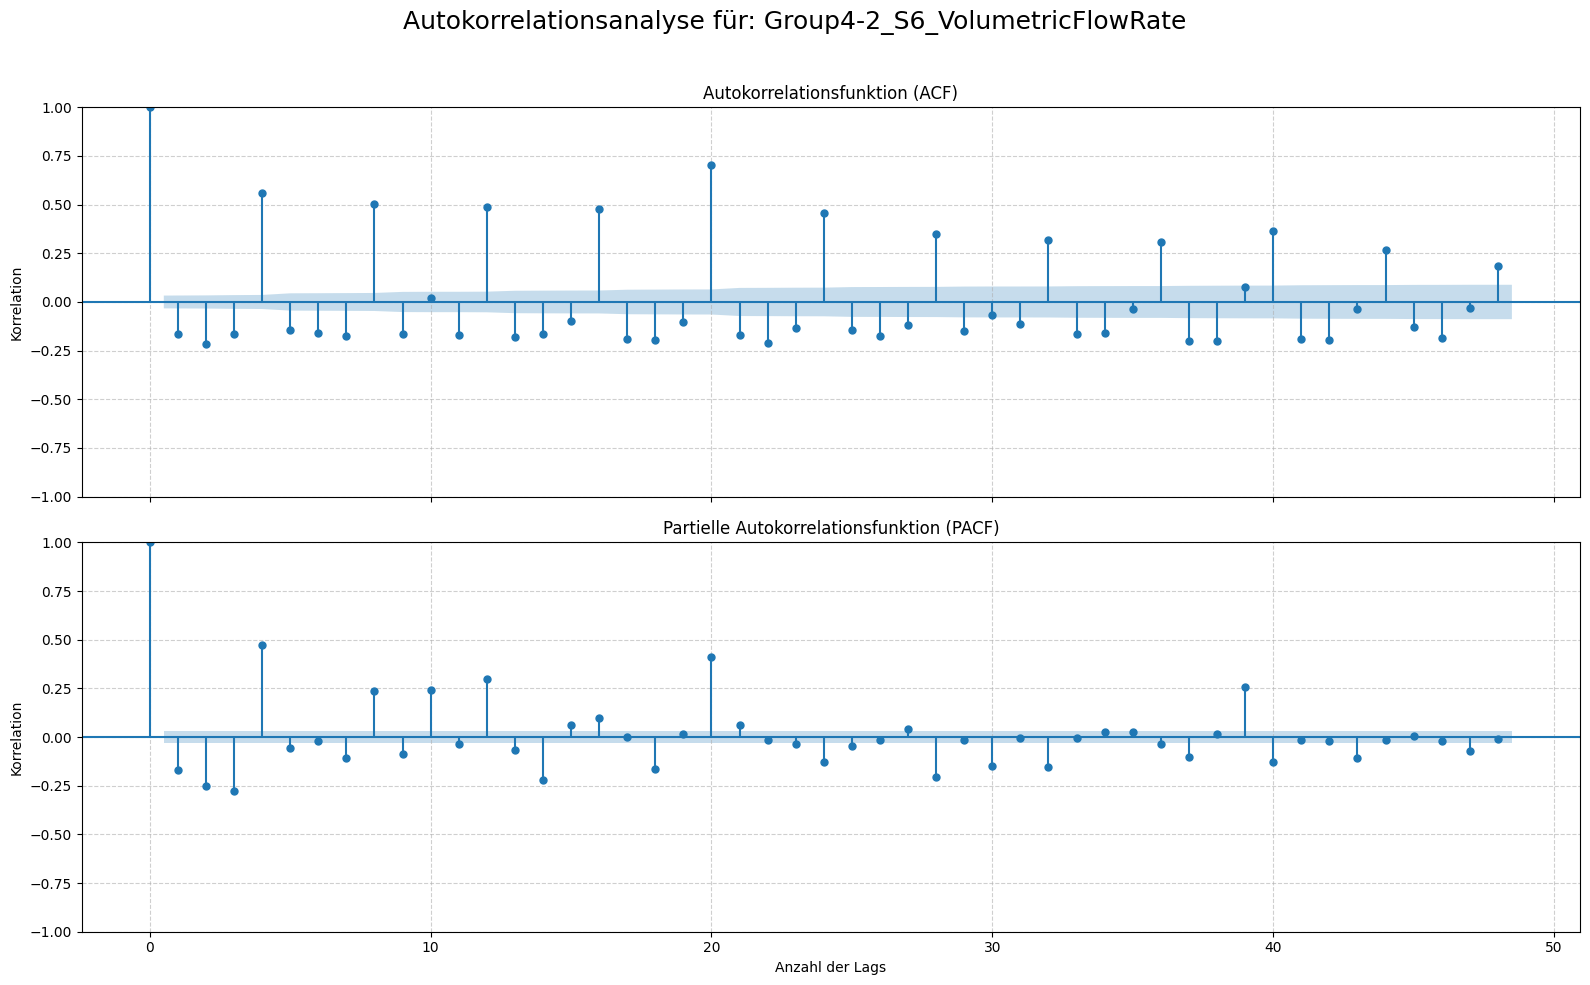

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from pathlib import Path
import warnings

# Ignoriere harmlose Matplotlib-Warnungen
warnings.filterwarnings("ignore", category=UserWarning)

# --- 1. Konfiguration ---
# Annahme: Ihr Notebook liegt in einem Unterordner (z.B. 'experiment').
# Das Hauptverzeichnis ('ML_Edge_Device') ist dann das 'parent'.
try:
    PROJECT_ROOT = Path.cwd().parent 
    file_path = PROJECT_ROOT / 'Input' / 'Input_Data' / 'mqtt_data_filtered.csv'
    
    if not file_path.is_file():
        raise FileNotFoundError
        
except FileNotFoundError:
    print("Konnte den Projekt-Pfad nicht automatisch finden.")
    file_path = input("Bitte geben Sie den vollständigen Pfad zur Datei 'mqtt_data_filtered.csv' ein: ")


datetime_col = 'datetime'
target_col = 'Group4-2_S6_VolumetricFlowRate'
max_lags_to_plot = 48

# --- 2. Daten laden und vorbereiten ---
try:
    df = pd.read_csv(file_path, parse_dates=[datetime_col], index_col=datetime_col)
    df = df.sort_index()
    time_series = df[target_col].dropna()
    
    print(f"✔ Daten erfolgreich geladen von: '{file_path}'")
    print(f"{len(time_series)} Datenpunkte werden für die Analyse verwendet.")
    print(f"Zeitraum der Daten: Von {time_series.index.min()} bis {time_series.index.max()}")

except (FileNotFoundError, KeyError) as e:
    print(f"❌ FEHLER beim Laden der Daten: {e}")
    time_series = None

# --- 3. ACF und PACF Werte berechnen und ausgeben (nur wenn Daten erfolgreich geladen wurden) ---
if time_series is not None and not time_series.empty:
    
    # Berechne die ACF- und PACF-Werte
    acf_values = acf(time_series, nlags=max_lags_to_plot)
    pacf_values = pacf(time_series, nlags=max_lags_to_plot)
    
    # Erstelle eine Tabelle für die Ausgabe
    results_df = pd.DataFrame({
        'ACF': acf_values,
        'PACF': pacf_values
    })
    results_df.index.name = 'Lag'

    print("\n" + "="*50)
    print("      BERECHNETE ACF- UND PACF-WERTE")
    print("="*50)
    # .to_string() sorgt dafür, dass die Tabelle nicht gekürzt wird
    print(results_df.to_string())
    print("="*50 + "\n")

    # Identifiziere signifikante Lags basierend auf dem 95% Konfidenzintervall
    # Die Formel für das Intervall ist ca. +/- 1.96 / sqrt(N)
    conf_interval = 1.96 / np.sqrt(len(time_series))
    
    # Finde alle Lags, deren PACF-Wert außerhalb des Konfidenzintervalls liegt
    # Wir ignorieren Lag 0, da dieser immer eine Korrelation von 1 mit sich selbst hat
    significant_pacf_lags = list(results_df.index[abs(results_df['PACF']) > conf_interval][1:])

    print("="*50)
    print("      SIGNIFIKANTE LAGS (BASIEREND AUF PACF)")
    print("="*50)
    print(f"Das 95% Konfidenzintervall liegt bei ca. ±{conf_interval:.4f}")
    print("Die folgenden Lags haben eine statistisch signifikante direkte Korrelation:")
    print(significant_pacf_lags)
    print("="*50 + "\n")


# --- 4. ACF und PACF plotten ---
if time_series is not None and not time_series.empty:
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Autokorrelationsanalyse für: {target_col}', fontsize=18)

    plot_acf(time_series, ax=axes[0], lags=max_lags_to_plot, title="Autokorrelationsfunktion (ACF)")
    axes[0].grid(linestyle='--', alpha=0.6)
    axes[0].set_ylabel("Korrelation")

    plot_pacf(time_series, ax=axes[1], lags=max_lags_to_plot, title="Partielle Autokorrelationsfunktion (PACF)")
    axes[1].grid(linestyle='--', alpha=0.6)
    axes[1].set_xlabel("Anzahl der Lags")
    axes[1].set_ylabel("Korrelation")
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Optuna-Optimierung (15 Läufe, Random Search)

In [18]:
best_rows = []

def make_objective(algo: str, level: str, horizon: int):
    
    def _objective(trial: optuna.Trial):
        """Eine Optuna-Trial-Funktion, die ein Modell trainiert und bewertet."""
        
        # === Parameter vorschlagen ===
        lags = trial.suggest_categorical('lags', [8, 12, 16, 20, 24])
        rolling_window = trial.suggest_int("rolling_window_size", 1, 12)
        
        # Konfiguration mit den Basiswerten erstellen
        cfg = _build_cfg(algo, level, lags=lags, horizon=horizon)
        
        ### KORREKTUR 1: rolling_window_size wirklich in die Config übernehmen ###
        # Diese Zeile stellt sicher, dass der vom Trial vorgeschlagene Wert auch im Trainer ankommt.
        cfg = _deep_merge(cfg, {"feature_engineering": {"rolling_window_size": rolling_window}})

        # Zusätzliche modellspezifische Hyperparameter vorschlagen
        # Die Funktion _suggest_additional_params gibt jetzt nur noch das `extra_top` dict zurück.
        # `lags` und `rolling_window` werden bereits hier im Objective definiert.
        extra_params_dict = _suggest_additional_params(trial, algo, cfg)
        
        # Training & Evaluierung durchführen
        return train_and_score(
            algo, level, lags, horizon, extra_params_dict, lock_structural=False
        )
        
    return _objective

for algo in ALGORITHMS:
    for level in LEVELS:
        print(f"\n=== Study: {algo} / {level} ===")
        
        ### KORREKTUR 2: Seed für jede Studie leicht variieren ###
        # Verhindert, dass der erste Trial jeder Studie identisch ist.
        derived_seed = 42 + hash((algo, level)) % 10000
        
        study = optuna.create_study(
            direction="minimize", 
            sampler=optuna.samplers.RandomSampler(seed=derived_seed)
        )
        
        # Optional: Erhöhe n_trials für eine gründlichere Suche, z.B. auf 50
        study.optimize(
            make_objective(algo, level, HORIZON), 
            n_trials=N_TRIALS_PER_RUN, 
            show_progress_bar=False
        )
        
        best = study.best_trial
        print(f"✅ Beste Metrik für {algo}/{level}: {best.value:.4f}")
        print(f"   Beste Parameter: {best.params}")

        row = {"algorithm": algo, "complexity": level, "horizon": HORIZON, "best_value": best.value}
        row.update(best.params)
        best_rows.append(row)

df_best = pd.DataFrame(best_rows)
df_best.to_csv(OUTPUT_CSV, index=False)
print(f"\nOptimierung abgeschlossen. Ergebnisse in '{OUTPUT_CSV}' gespeichert.")
df_best

[I 2025-08-28 14:31:25,824] A new study created in memory with name: no-name-ff9aeb65-33a9-4049-bf8e-5b0e2f17c95b
2025-08-28 14:31:25,826 - INFO - --- 🚀 Starting lstm_simple Training Pipeline ---
2025-08-28 14:31:25,828 - INFO - 
Step 1: Preparing training data...
2025-08-28 14:31:25,887 - INFO - Ordne Features neu an, um Target 'group4-2_s6_volumetricflowrate' an Position 0 zu platzieren.
C:\DEV\RevPi_ML\ML_Edge_Device\ML_Helpfunctions\Load_Prepare_Data.py:446: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_featured.dropna(inplace=True)
2025-08-28 14:31:25,916 - INFO - Die zu speichernde Feature-Liste für die Inferenz enthält 38 Spalten.
2025-08-28 14:31:25,917 - INFO - Data preparation complete. Features: 38, X_train shape: (2624, 16, 38)
2025-08-28 14:31:25,917 - INFO - 
Step 2: Training mod


=== Study: lstm / simple ===
--- Starte 3D Trainings-Pipeline (Korrigierte Version) ---

Lade Daten im Modus 'train' mit Strategie 'split'...
✔️ Datendatei gefunden: C:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv
Geladen: 3542 Zeilen aus 'C:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv' mit Zeitfeatures
✔️ Datendatei gefunden: C:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv
Geladen: 3542 Zeilen aus 'C:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv' mit Zeitfeatures
Nach FE und dropna verbleiben 2640 Zeilen für das Training.

Schritt 3: Scaler anpassen...
✅ Haupt-Scaler (scaler) wurde auf ALLEN Spalten angepasst.
✅ Target-Scaler (y_scaler) wurde NUR auf der Target-Spalte angepasst.

Schritt 4: Gesamte Daten skalieren und 3D-Fenster erstellen...

Trainings-Pipeline abgeschlossen. Shapes: X_train: (2624, 16, 38), y_train: (2624, 1)
Erstelle chronologischen Validierungs-Split. Validation Fraction: 

2025-08-28 14:31:34,576 - INFO - ✅ Model training completed in 8.39 seconds.
2025-08-28 14:31:34,577 - INFO - 
Step 3: Returning trained artifacts without saving.
2025-08-28 14:31:34,579 - INFO - 
✅ Training pipeline finished successfully.
[I 2025-08-28 14:31:34,581] Trial 0 finished with value: 1000000000.0 and parameters: {'lags': 16, 'rolling_window_size': 10, 'dropout': 0.35023858085720627, 'batch_size': 64, 'epochs': 100, 'learning_rate': 0.00015871330654100967, 'optimizer': 'nadam', 'loss': 'huber', 'clipnorm': 0.7164438608677481, 'weight_decay': 3.876999147886564e-08}. Best is trial 0 with value: 1000000000.0.
2025-08-28 14:31:34,584 - INFO - --- 🚀 Starting lstm_simple Training Pipeline ---
2025-08-28 14:31:34,585 - INFO - 
Step 1: Preparing training data...


--- Starte 3D Trainings-Pipeline (Korrigierte Version) ---

Lade Daten im Modus 'train' mit Strategie 'split'...
✔️ Datendatei gefunden: C:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv
Geladen: 3542 Zeilen aus 'C:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv' mit Zeitfeatures
✔️ Datendatei gefunden: C:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv
Geladen: 3542 Zeilen aus 'C:\DEV\RevPi_ML\ML_Edge_Device\Input\Input_Data\mqtt_data_filtered.csv' mit Zeitfeatures


2025-08-28 14:31:34,637 - INFO - Ordne Features neu an, um Target 'group4-2_s6_volumetricflowrate' an Position 0 zu platzieren.
C:\DEV\RevPi_ML\ML_Edge_Device\ML_Helpfunctions\Load_Prepare_Data.py:446: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_featured.dropna(inplace=True)
2025-08-28 14:31:34,669 - INFO - Die zu speichernde Feature-Liste für die Inferenz enthält 46 Spalten.
2025-08-28 14:31:34,670 - INFO - Data preparation complete. Features: 46, X_train shape: (2616, 20, 46)
2025-08-28 14:31:34,670 - INFO - 
Step 2: Training model...


...

2025-08-28 15:44:55,797 - INFO - Die zu speichernde Feature-Liste für die Inferenz enthält 30 Spalten.
2025-08-28 15:44:55,797 - INFO - Data preparation complete. Features: 30, X_train shape: (2643, 30)
2025-08-28 15:44:55,799 - INFO - 
Step 2: Training model...
2025-08-28 15:44:55,985 - INFO - Light_XGBoost-Training abgeschlossen in 0.18 s.



Schritt 3: Richte Features (X_t) auf zukünftige Zielvariable (Y_{t+1...t+h}) aus...
Nach Ausrichtung und NaN-Filterung verbleiben 2643 Trainingspunkte.

Schritt 4: Skalierung und finale Formatierung...
Passe Feature-Scaler (scaler) auf Trainingsdaten an...
Passe Target-Scaler (y_scaler) auf Trainingsdaten an...

Trainings-Pipeline abgeschlossen. Shapes: X_train: (2643, 30), y_train: (2643, 1)
[LightGBM] [Warning] feature_fraction is set=0.75, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.75
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.75, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.75
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM

2025-08-28 15:44:55,986 - INFO - ✅ Model training completed in 0.18 seconds.
2025-08-28 15:44:55,986 - INFO - 
Step 3: Returning trained artifacts without saving.
2025-08-28 15:44:55,987 - INFO - 
✅ Training pipeline finished successfully.
[I 2025-08-28 15:44:55,988] Trial 29 finished with value: 1000000000.0 and parameters: {'lags': 12, 'rolling_window_size': 3, 'learning_rate': 0.005184570060542547, 'subsample': 0.864225289239076, 'colsample_bytree': 0.8062954479485691, 'min_child_weight': 10, 'reg_lambda': 0.05093730233331277, 'reg_alpha': 4.519752995384198e-05, 'min_child_samples': 168, 'max_bin': 512}. Best is trial 0 with value: 1000000000.0.


✅ Beste Metrik für light_xgboost/high: 1000000000.0000
   Beste Parameter: {'lags': 20, 'rolling_window_size': 10, 'learning_rate': 0.02330705201719868, 'subsample': 0.7452450194299439, 'colsample_bytree': 0.8878706699319282, 'min_child_weight': 11, 'reg_lambda': 0.0028801207223379914, 'reg_alpha': 0.0026668218090420462, 'min_child_samples': 126, 'max_bin': 160}

Optimierung abgeschlossen. Ergebnisse in 'BestParams_15Runsv2.csv' gespeichert.


,algorithm,complexity,horizon,best_value,lags,rolling_window_size,dropout,batch_size,epochs,learning_rate,...,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha,gamma,max_delta_step,grow_policy,min_child_samples,max_bin
0,lstm,simple,1,1.000000e+09,16,10,0.350239,64.0,100.0,0.000159,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lstm,medium,1,1.000000e+09,20,3,0.409151,32.0,40.0,0.000803,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lstm,high,1,1.000000e+09,16,7,0.312020,32.0,40.0,0.003931,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cnn1d,simple,1,1.000000e+09,20,11,NaN,128.0,40.0,0.001296,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cnn1d,medium,1,1.000000e+09,20,9,NaN,128.0,90.0,0.000211,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cnn1d,high,1,1.000000e+09,8,6,NaN,32.0,90.0,0.000347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,random_forest,simple,1,1.000000e+09,24,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,random_forest,medium,1,1.000000e+09,16,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,random_forest,high,1,1.000000e+09,12,7,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,xgboost,simple,1,1.000000e+09,20,12,NaN,NaN,NaN,0.005002,...,0.812976,0.407343,15.0,0.015603,0.001448,4.352166,5.995196,lossguide,NaN,NaN



### Hinweise
- **Persistenz**: Modelle, Scaler und Fehlermetriken werden **nicht** gespeichert. Es wird nur `BestParams_15Runs.csv` geschrieben.
- **Feature-Flags** (`include_roll_mean/std`, `rolling_window_size`) sind **fix** gesetzt und **nicht** Teil der Optimierung.
- **Komplexitäts-Parameter** aus den Presets werden **nicht** verändert; HPO überschreibt nur nicht-strukturelle Trainings-/Reg-Parameter.
- Dataset-Pfade werden **wie in der Pipeline** über `CONFIG_PATH['paths']` abgeleitet; der Vorab-Check ist informativ.
